# Glyph — Evaluation Notebook

This notebook measures the following metrics:

1. Response Accuracy
2. Retrieval Relevance
3. Average Response Latency
4. User Satisfaction


## 1. Setting up the environment

From the root of the Glyph repository, install the backend dependencies:

```bash
cd backend
pip install -r requirements.txt
```

Make sure your `backend/.env` contains:

```env
GROQ_API_KEY=your_key
GROQ_MODEL_NAME=llama-3.3-70b-versatile
```

The evaluation CSV containa:

- `id`
- `pdf`
- `question`
- `reference_answer`
- `relevant_pages`
- `difficulty`
- `satisfaction`

`reference_answer` is the human-written correct answer used for accuracy evaluation.

In [ ]:
# 2. Imports and paths

from pathlib import Path
import sys
import os
import json
import time
import re
import uuid

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_FILE = Path.cwd() / "evaluation.ipynb"

if not NOTEBOOK_FILE.exists():
    # Search current directory and its parents for the notebook.
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        possible = candidate / "notebooks" / "evaluation.ipynb"
        if possible.exists():
            NOTEBOOK_FILE = possible
            break

if NOTEBOOK_FILE.exists():
    NOTEBOOK_DIR = NOTEBOOK_FILE.parent
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    # Fallback for environments where the notebook file is not visible.
    # This works when the notebook is launched from either Glyph/ or Glyph/notebooks/.
    if Path.cwd().name == "notebooks":
        NOTEBOOK_DIR = Path.cwd()
        PROJECT_ROOT = NOTEBOOK_DIR.parent
    elif (Path.cwd() / "notebooks" / "evaluation_data").exists():
        PROJECT_ROOT = Path.cwd()
        NOTEBOOK_DIR = PROJECT_ROOT / "notebooks"
    else:
        NOTEBOOK_DIR = Path.cwd()
        PROJECT_ROOT = Path.cwd()

BACKEND_DIR = PROJECT_ROOT / "backend"

# Evaluation data is stored alongside this notebook.
EVAL_DIR = NOTEBOOK_DIR / "evaluation_data"
PDF_DIR = EVAL_DIR / "pdfs"
RESULTS_DIR = NOTEBOOK_DIR / "evaluation_results"

PDF_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

backend_path = str(BACKEND_DIR.resolve())
if backend_path not in sys.path:
    sys.path.insert(0, backend_path)

print("Project root:", PROJECT_ROOT.resolve())
print("Notebook directory:", NOTEBOOK_DIR.resolve())
print("Backend:", BACKEND_DIR.resolve())
print("Evaluation data:", EVAL_DIR.resolve())
print("Evaluation PDFs:", PDF_DIR.resolve())
print("Results:", RESULTS_DIR.resolve())


Project root: E:\kajal\Engg\Glyph
Notebook directory: E:\kajal\Engg\Glyph\notebooks
Backend: E:\kajal\Engg\Glyph\backend
Evaluation data: E:\kajal\Engg\Glyph\notebooks\evaluation_data
Evaluation PDFs: E:\kajal\Engg\Glyph\notebooks\evaluation_data\pdfs
Results: E:\kajal\Engg\Glyph\notebooks\evaluation_results


In [2]:
# 3. Import Glyph's actual production RAG functions

# Load the backend .env explicitly so rag.py can read Groq settings when the
# notebook is executed from the notebooks directory.
from dotenv import load_dotenv
dotenv_path = BACKEND_DIR / ".env"
if dotenv_path.exists():
    load_dotenv(dotenv_path)

from rag import (
    get_pdf_text,
    get_vector_store,
    get_conversation_chain,
)

print("Successfully imported Glyph's production RAG pipeline.")
print("Using get_vector_store:", get_vector_store)
print("Using get_conversation_chain:", get_conversation_chain)


Successfully imported Glyph's production RAG pipeline.
Using get_vector_store: <function get_vector_store at 0x000001D3342DF320>
Using get_conversation_chain: <function get_conversation_chain at 0x000001D334317950>


## 4. Evaluation Dataset

In [3]:
EVAL_CSV = EVAL_DIR / "evaluation_questions.csv"

if not EVAL_CSV.exists():
    template = pd.DataFrame([
        {
            "id": "Q01",
            "pdf": "REPLACE_WITH_REAL_PDF",
            "question": "Replace with a real question from your PDF.",
            "reference_answer": "Replace with the correct answer supported by the PDF.",
            "relevant_pages": "1",
            "difficulty": "easy",
            "satisfaction": ""
        }
    ])
    template.to_csv(EVAL_CSV, index=False)
    print("Created template:", EVAL_CSV)
    print("Edit this file, then rerun this cell.")
else:
    print("Found evaluation dataset:", EVAL_CSV)

eval_df = pd.read_csv(EVAL_CSV)

required_columns = ["id", "pdf", "question", "reference_answer"]
missing = [c for c in required_columns if c not in eval_df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

eval_df.head()

Found evaluation dataset: e:\kajal\Engg\Glyph\notebooks\evaluation_data\evaluation_questions.csv


,id,pdf,question,reference_answer,relevant_pages,difficulty
0,OCR01,evaluation_document_ocr_and_rag.pdf,Why is the quality of the knowledge base impor...,The knowledge base defines the information ava...,1,easy
1,OCR02,evaluation_document_ocr_and_rag.pdf,What is OHRBench designed to evaluate?,OHRBench is designed to study the cascading im...,3,easy
2,OCR03,evaluation_document_ocr_and_rag.pdf,How many documents and question-answer pairs a...,OHRBench contains 350 unstructured PDF documen...,3,easy
3,OCR04,evaluation_document_ocr_and_rag.pdf,What are the six application domains represent...,"The six domains are textbook, manual, academic...",3,easy
4,OCR05,evaluation_document_ocr_and_rag.pdf,What are the two primary types of OCR noise id...,The two types are Semantic Noise and Formattin...,4,easy


In [4]:
# 5. Validate that all referenced PDFs exist

# Normalize filenames so Windows/macOS/Linux path differences do not cause
# false "missing PDF" errors.
available_pdfs = {
    p.name.lower(): p
    for p in PDF_DIR.glob("*.pdf")
    if p.is_file()
}

missing_pdfs = []
resolved_pdf_paths = {}

for pdf_name in eval_df["pdf"].dropna().astype(str).str.strip().unique():
    requested_name = Path(pdf_name).name
    requested_key = requested_name.lower()

    if requested_key in available_pdfs:
        resolved_pdf_paths[requested_name] = available_pdfs[requested_key]
    else:
        missing_pdfs.append(requested_name)

if missing_pdfs:
    print("Missing PDFs referenced by evaluation_questions.csv:")
    for p in missing_pdfs:
        print(" -", p)

    print(f"\nPDF folder being searched:")
    print(" ", PDF_DIR.resolve())

    print("\nPDFs currently found in that folder:")
    if available_pdfs:
        for p in sorted(available_pdfs.values()):
            print(" -", p.name)
    else:
        print(" - No PDF files found.")

    print(
        "\nMake sure the PDF filenames in evaluation_questions.csv "
        "exactly match files in notebooks/evaluation_data/pdfs/."
    )
    raise FileNotFoundError(
        f"{len(missing_pdfs)} evaluation PDF(s) referenced in the CSV were not found."
    )
else:
    print(f"All {len(resolved_pdf_paths)} evaluation PDF(s) found.")

    for name, path in resolved_pdf_paths.items():
        print(f" - {name} -> {path}")


All 2 evaluation PDF(s) found.
 - evaluation_document_ocr_and_rag.pdf -> e:\kajal\Engg\Glyph\notebooks\evaluation_data\pdfs\evaluation_document_ocr_and_rag.pdf
 - evaluation_document_mobile_learning.pdf -> e:\kajal\Engg\Glyph\notebooks\evaluation_data\pdfs\evaluation_document_mobile_learning.pdf


## 6. Build Glyph's Actual FAISS Vector Store

In [5]:
# Build file-like objects in the same form expected by Glyph's get_vector_store().

class EvaluationPDFFile:
    def __init__(self, path):
        self.path = Path(path)
        self.name = self.path.name
        self.filename = self.path.name
        self._file = open(self.path, "rb")

    def seek(self, *args):
        return self._file.seek(*args)

    def read(self, *args):
        return self._file.read(*args)

    def close(self):
        if not self._file.closed:
            self._file.close()


# Use the paths resolved during PDF validation.
# This also handles case differences in filenames on case-sensitive systems.
pdf_paths = list(resolved_pdf_paths.values())

if not pdf_paths:
    raise FileNotFoundError(
        f"No evaluation PDFs were resolved from {EVAL_CSV.resolve()}. "
        f"Expected PDFs under {PDF_DIR.resolve()}."
    )

missing_paths = [p for p in pdf_paths if not p.exists()]
if missing_paths:
    missing_list = "\n".join(str(p) for p in missing_paths)
    raise FileNotFoundError(
        "One or more evaluation PDFs are missing. "
        f"Expected files under {PDF_DIR.resolve()}.\n"
        "Missing files:\n" + missing_list
    )

pdf_files = [EvaluationPDFFile(p) for p in pdf_paths]

print("PDFs used for evaluation:")
for p in pdf_paths:
    print(" -", p.name)

vector_store, chunk_count = get_vector_store(pdf_files)

# Close local file handles after the vector store has been created.
for pdf_file in pdf_files:
    pdf_file.close()

print(f"Glyph created FAISS vector store with {chunk_count} chunks.")


PDFs used for evaluation:
 - evaluation_document_ocr_and_rag.pdf
 - evaluation_document_mobile_learning.pdf


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Glyph created FAISS vector store with 10 chunks.


## 7. Create Glyph's Actual Conversational RAG Chain

This is the actual production chain, not a separate evaluation-only implementation.

In [6]:
conversation_chain = get_conversation_chain(vector_store)

print("Glyph ConversationalRetrievalChain created successfully.")
print("LLM and retriever are configured by backend/rag.py.")

E:\kajal\Engg\Glyph\backend\rag.py:56: LangChainDeprecationWarning: The class `ConversationBufferMemory` was deprecated in LangChain 0.3.1 and will be removed in 2.0.0. Use `langchain.agents.create_agent` instead. For agents that need to remember prior interactions, use `create_agent` with checkpointing or the `Store` API. See https://docs.langchain.com/oss/python/langchain/short-term-memory and https://docs.langchain.com/oss/python/langchain/long-term-memory
  mem=ConversationBufferMemory(memory_key="chat_history",return_messages=True,output_key="answer")


Glyph ConversationalRetrievalChain created successfully.
LLM and retriever are configured by backend/rag.py.


## 8. Run One Test Question

Before running the full evaluation, test one question.

In [7]:
test_question = str(eval_df.iloc[0]["question"])

# Ask the same chain used by Glyph.
start = time.perf_counter()
test_response = conversation_chain.invoke({"question": test_question})
test_latency = time.perf_counter() - start

print("QUESTION:")
print(test_question)

print("\nANSWER:")
print(test_response.get("answer", ""))

print("\nLATENCY:")
print(f"{test_latency:.3f} seconds")

print("\nRETRIEVED SOURCES:")
for i, doc in enumerate(test_response.get("source_documents", []), start=1):
    print(
        f"{i}. "
        f"document={doc.metadata.get('document')} | "
        f"page={doc.metadata.get('page')} | "
        f"chunk={doc.metadata.get('chunk')}"
    )



> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Use only the context. If unknown, say you don't know.

Context:
Evaluation Document | Page 5
9. OCR and End-to-End RAG
OCR errors can propagate through the RAG pipeline. A parsing error can alter the knowledge base, reduce
retrieval quality, and then affect the evidence available to the language model. The study therefore treats document
parsing as an upstream component whose errors can cascade into retrieval, generation, and overall system
performance.
10. Implications for RAG Applications
The results suggest that improving the retriever or language model alone is not enough when the knowledge base
is built from noisy OCR. RAG systems that process complex PDFs should consider document parsing quality as
part of the evaluation pipeline. The study also discusses Vision-Language Models (VLMs) as a possible alternative
or complement to OCR. Combining visual input with OCR text was rep

## 9. Run the Full Evaluation

For every question, the notebook records:

- generated answer,
- latency,
- retrieved document count,
- retrieved document names,
- retrieved page numbers,
- retrieved chunk IDs.

A fresh chain is **not** created for every question because Glyph is conversational and uses `ConversationBufferMemory`. Questions belonging to the same evaluation session should therefore be ordered intentionally.

For independent question evaluation, the notebook uses a fresh chain for each question. This prevents one test question's chat history from affecting another question's answer.

This makes the accuracy/retrieval evaluation cleaner and avoids cross-question contamination.

In [8]:
def make_fresh_glyph_chain():
    # Reuse the same vector store, but create fresh memory.
    return get_conversation_chain(vector_store)


def run_single_evaluation(row):
    chain = make_fresh_glyph_chain()

    question = str(row["question"])

    start = time.perf_counter()
    response = chain.invoke({"question": question})
    latency = time.perf_counter() - start

    answer = response.get("answer", "")
    source_docs = response.get("source_documents", [])

    source_records = []
    for doc in source_docs:
        source_records.append({
            "document": doc.metadata.get("document"),
            "page": doc.metadata.get("page"),
            "chunk": doc.metadata.get("chunk"),
        })

    return {
        "id": row["id"],
        "pdf": row["pdf"],
        "question": question,
        "reference_answer": row["reference_answer"],
        "generated_answer": answer,
        "latency_sec": latency,
        "retrieved_count": len(source_docs),
        "retrieved_sources": json.dumps(source_records),
        "retrieved_documents": ", ".join(
            sorted(set(str(x["document"]) for x in source_records if x["document"] is not None))
        ),
        "retrieved_pages": ", ".join(
            sorted(set(str(x["page"]) for x in source_records if x["page"] is not None))
        ),
        "retrieved_chunks": ", ".join(
            sorted(set(str(x["chunk"]) for x in source_records if x["chunk"] is not None))
        ),
        "correct_binary": "",
        "partial_score": "",
        "retrieval_relevant": "",
        "satisfaction": row.get("satisfaction", ""),
        "failure_case": "",
    }


evaluation_outputs = []

for idx, row in eval_df.iterrows():
    print(f"Running {idx + 1}/{len(eval_df)}: {row['id']}")

    try:
        result = run_single_evaluation(row)
        evaluation_outputs.append(result)

        print(f"  latency: {result['latency_sec']:.3f}s")
        print(f"  retrieved: {result['retrieved_count']} chunks")
    except Exception as e:
        print("  ERROR:", repr(e))
        evaluation_outputs.append({
            "id": row["id"],
            "pdf": row["pdf"],
            "question": row["question"],
            "reference_answer": row["reference_answer"],
            "generated_answer": "",
            "latency_sec": np.nan,
            "retrieved_count": 0,
            "retrieved_sources": "[]",
            "retrieved_documents": "",
            "retrieved_pages": "",
            "retrieved_chunks": "",
            "correct_binary": "",
            "partial_score": "",
            "retrieval_relevant": "",
            "satisfaction": row.get("satisfaction", ""),
            "failure_case": f"Pipeline error: {repr(e)}",
        })

results_df = pd.DataFrame(evaluation_outputs)

print("\nEvaluation run complete.")
results_df[[
    "id", "question", "generated_answer", "latency_sec",
    "retrieved_count", "retrieved_documents", "retrieved_pages"
]]

Running 1/20: OCR01


> Entering new StuffDocumentsChain chain...


> Entering new LLMChain chain...
Prompt after formatting:
Use only the context. If unknown, say you don't know.

Context:
Evaluation Document | Page 5
9. OCR and End-to-End RAG
OCR errors can propagate through the RAG pipeline. A parsing error can alter the knowledge base, reduce
retrieval quality, and then affect the evidence available to the language model. The study therefore treats document
parsing as an upstream component whose errors can cascade into retrieval, generation, and overall system
performance.
10. Implications for RAG Applications
The results suggest that improving the retriever or language model alone is not enough when the knowledge base
is built from noisy OCR. RAG systems that process complex PDFs should consider document parsing quality as
part of the evaluation pipeline. The study also discusses Vision-Language Models (VLMs) as a possible alternative
or complement to OCR. Combining visual input w

,id,question,generated_answer,latency_sec,retrieved_count,retrieved_documents,retrieved_pages
0,OCR01,Why is the quality of the knowledge base impor...,The quality of the knowledge base is important...,1.208164,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
1,OCR02,What is OHRBench designed to evaluate?,OHRBench is designed to evaluate the cascading...,0.387471,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
2,OCR03,How many documents and question-answer pairs a...,OHRBench contains 350 unstructured PDF documen...,0.283477,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4"
3,OCR04,What are the six application domains represent...,The six application domains represented in OHR...,0.419158,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4"
4,OCR05,What are the two primary types of OCR noise id...,The two primary types of OCR noise identified ...,0.621353,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
5,OCR06,How does Semantic Noise differ from Formatting...,Semantic Noise differs from Formatting Noise i...,0.495864,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
6,OCR07,Which metrics are used to evaluate retrieval a...,The metrics used to evaluate retrieval are Lon...,0.346583,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4"
7,OCR08,What happens to RAG performance as Semantic No...,RAG performance experiences substantial degrad...,0.305438,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
8,OCR09,Why can OCR errors cause cascading failures in...,OCR errors can cause cascading failures in a R...,0.397433,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5"
9,OCR10,What alternative to OCR does the study discuss...,The study discusses Vision-Language Models (VL...,0.466197,6,"evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 5"


## 10. Manual Evaluation

Inspect each generated answer against the reference answer.

Fill in:

### `correct_binary`
- `1` = correct and sufficiently complete
- `0` = incorrect

### `partial_score`
- `1` = fully correct
- `0.5` = partially correct or incomplete
- `0` = incorrect

### `retrieval_relevant`
- `1` = retrieved chunks contain relevant evidence needed to answer
- `0` = retrieved chunks are not relevant

### `satisfaction`
- 1 to 5 based on human evaluator judgment


In [9]:
RAW_RESULTS_CSV = RESULTS_DIR / "evaluation_results_raw.csv"

results_df.to_csv(RAW_RESULTS_CSV, index=False)

print("Raw evaluation results saved to:")
print(RAW_RESULTS_CSV)
print("\nOpen this CSV and fill the manual evaluation columns:")
print("- correct_binary")
print("- partial_score")
print("- retrieval_relevant")
print("- satisfaction")
print("- failure_case")

Raw evaluation results saved to:
e:\kajal\Engg\Glyph\notebooks\evaluation_results\evaluation_results_raw.csv

Open this CSV and fill the manual evaluation columns:
- correct_binary
- partial_score
- retrieval_relevant
- satisfaction
- failure_case


In [12]:
# Reload manually scored results after editing the CSV.

SCORED_RESULTS_CSV = RESULTS_DIR / "evaluation_results_scored.csv"

if SCORED_RESULTS_CSV.exists():
    scored_df = pd.read_csv(SCORED_RESULTS_CSV)
    print("Loaded scored results:", SCORED_RESULTS_CSV)
else:
    print("No scored CSV found yet.")
    print("For convenience, the raw results are currently loaded.")
    scored_df = results_df.copy()

scored_df.head()

Loaded scored results: e:\kajal\Engg\Glyph\notebooks\evaluation_results\evaluation_results_scored.csv


,id,pdf,question,reference_answer,generated_answer,latency_sec,retrieved_count,retrieved_sources,retrieved_documents,retrieved_pages,retrieved_chunks,correct_binary,partial_score,retrieval_relevant,satisfaction
0,OCR01,evaluation_document_ocr_and_rag.pdf,Why is the quality of the knowledge base impor...,The knowledge base defines the information ava...,The quality of the knowledge base is important...,1.208164,6,"[{""document"": ""evaluation_document_ocr_and_rag...","evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5",1,1,1.0,1,5
1,OCR02,evaluation_document_ocr_and_rag.pdf,What is OHRBench designed to evaluate?,OHRBench is designed to study the cascading im...,OHRBench is designed to evaluate the cascading...,0.387471,6,"[{""document"": ""evaluation_document_ocr_and_rag...","evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5",1,1,0.5,1,4
2,OCR03,evaluation_document_ocr_and_rag.pdf,How many documents and question-answer pairs a...,OHRBench contains 350 unstructured PDF documen...,OHRBench contains 350 unstructured PDF documen...,0.283477,6,"[{""document"": ""evaluation_document_ocr_and_rag...","evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4",1,1,1.0,1,5
3,OCR04,evaluation_document_ocr_and_rag.pdf,What are the six application domains represent...,"The six domains are textbook, manual, academic...",The six application domains represented in OHR...,0.419158,6,"[{""document"": ""evaluation_document_ocr_and_rag...","evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4",1,1,1.0,1,5
4,OCR05,evaluation_document_ocr_and_rag.pdf,What are the two primary types of OCR noise id...,The two types are Semantic Noise and Formattin...,The two primary types of OCR noise identified ...,0.621353,6,"[{""document"": ""evaluation_document_ocr_and_rag...","evaluation_document_mobile_learning.pdf, evalu...","1, 2, 3, 4, 5",1,1,1.0,1,5


## 11. Calculate the Metrics

In [13]:
def numeric_values(series):
    return pd.to_numeric(series, errors="coerce").dropna()


accuracy_binary = numeric_values(scored_df["correct_binary"])
partial_scores = numeric_values(scored_df["partial_score"])
retrieval_scores = numeric_values(scored_df["retrieval_relevant"])
latencies = numeric_values(scored_df["latency_sec"])
satisfaction_scores = numeric_values(scored_df["satisfaction"])

response_accuracy_pct = (
    accuracy_binary.mean() * 100 if len(accuracy_binary) else np.nan
)

response_accuracy_partial_pct = (
    partial_scores.mean() * 100 if len(partial_scores) else np.nan
)

retrieval_relevance_pct = (
    retrieval_scores.mean() * 100 if len(retrieval_scores) else np.nan
)

average_latency_sec = (
    latencies.mean() if len(latencies) else np.nan
)

user_satisfaction_5 = (
    satisfaction_scores.mean() if len(satisfaction_scores) else np.nan
)

metrics = pd.DataFrame({
    "Metric": [
        "Response Accuracy",
        "Response Accuracy (Partial Credit)",
        "Retrieval Relevance",
        "Average Response Latency",
        "User Satisfaction"
    ],
    "Measured Value": [
        f"{response_accuracy_pct:.2f}%" if not np.isnan(response_accuracy_pct) else "N/A",
        f"{response_accuracy_partial_pct:.2f}%" if not np.isnan(response_accuracy_partial_pct) else "N/A",
        f"{retrieval_relevance_pct:.2f}%" if not np.isnan(retrieval_relevance_pct) else "N/A",
        f"{average_latency_sec:.2f} sec" if not np.isnan(average_latency_sec) else "N/A",
        f"{user_satisfaction_5:.2f}/5" if not np.isnan(user_satisfaction_5) else "N/A",
    ]
})

metrics

,Metric,Measured Value
0,Response Accuracy,95.00%
1,Response Accuracy (Partial Credit),87.50%
2,Retrieval Relevance,85.00%
3,Average Response Latency,3.19 sec
4,User Satisfaction,4.40/5


## 12. Target/Baseline vs. Notebook Measurements

In [16]:
comparison = pd.DataFrame({
    "Metric": [
        "Response Accuracy",
        "Retrieval Relevance",
        "Average Latency",
        "User Satisfaction"
    ],
    "Target / Baseline": [
        "85%",
        "80%",
        "<5 seconds",
        ">4/5"
    ],
    "Notebook Measured": [
        f"{response_accuracy_pct:.2f}%" if not np.isnan(response_accuracy_pct) else "N/A",
        f"{retrieval_relevance_pct:.2f}%" if not np.isnan(retrieval_relevance_pct) else "N/A",
        f"{average_latency_sec:.2f} sec" if not np.isnan(average_latency_sec) else "N/A",
        f"{user_satisfaction_5:.2f}/5" if not np.isnan(user_satisfaction_5) else "N/A",
    ]
})

comparison

,Metric,Target / Baseline,Notebook Measured
0,Response Accuracy,85%,95.00%
1,Retrieval Relevance,80%,85.00%
2,Average Latency,<5 seconds,3.19 sec
3,User Satisfaction,>4/5,4.40/5


## 13. Visualizations

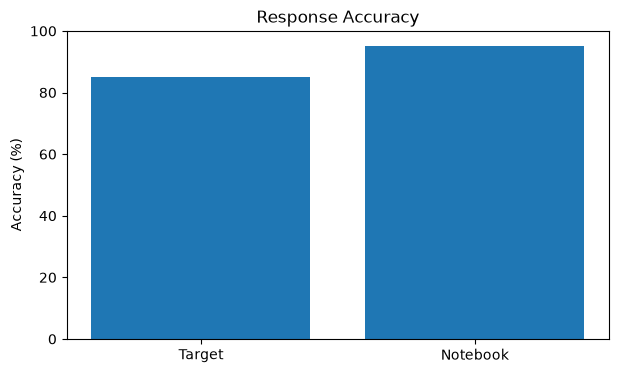

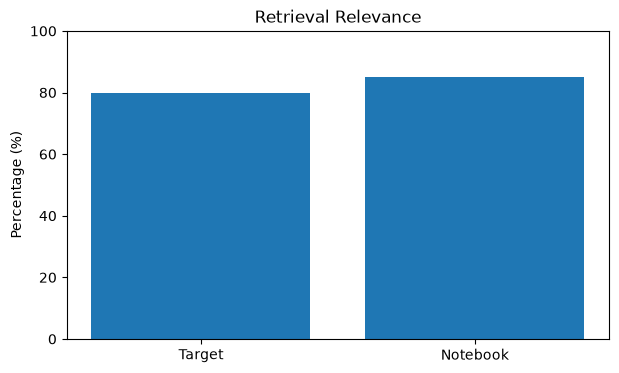

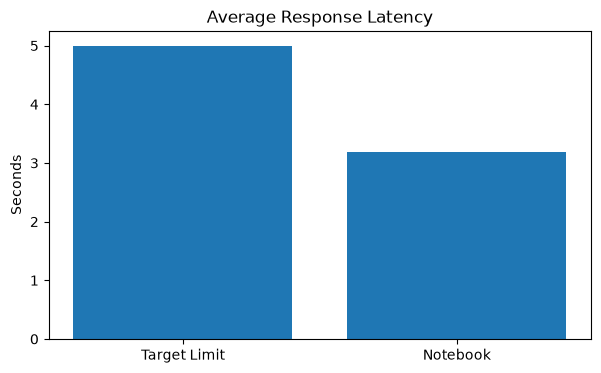

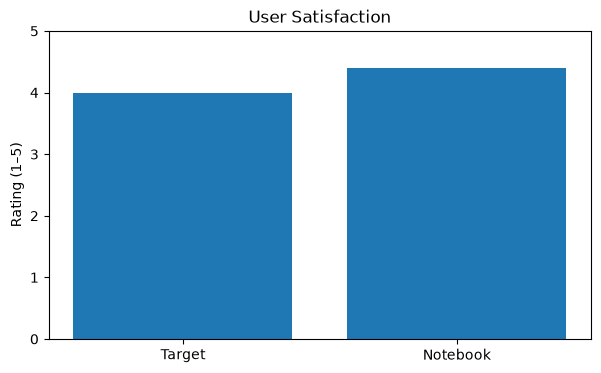

In [20]:
# Response Accuracy
if not np.isnan(response_accuracy_pct):
    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Target", "Notebook"],
        [85, response_accuracy_pct]
    )
    plt.ylabel("Accuracy (%)")
    plt.title("Response Accuracy")
    plt.ylim(0, 100)
    plt.show()

# Retrieval Relevance
if not np.isnan(retrieval_relevance_pct):
    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Target", "Notebook"],
        [80, retrieval_relevance_pct]
    )
    plt.ylabel("Percentage (%)")
    plt.title("Retrieval Relevance")
    plt.ylim(0, 100)
    plt.show()

# Latency
if not np.isnan(average_latency_sec):
    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Target Limit", "Notebook"],
        [5, average_latency_sec]
    )
    plt.ylabel("Seconds")
    plt.title("Average Response Latency")
    plt.show()

# Satisfaction
if not np.isnan(user_satisfaction_5):
    plt.figure(figsize=(7, 4))
    plt.bar(
        ["Target", "Notebook"],
        [4, user_satisfaction_5]
    )
    plt.ylabel("Rating (1–5)")
    plt.title("User Satisfaction")
    plt.ylim(0, 5)
    plt.show()

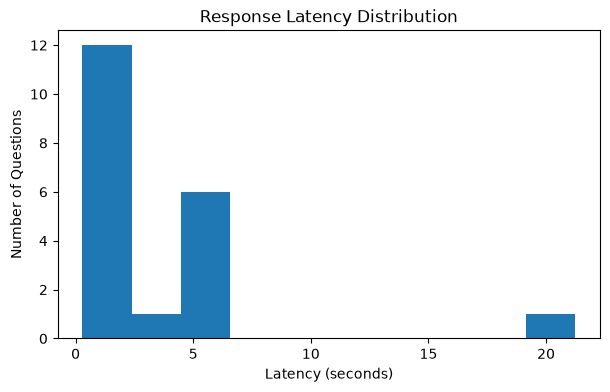

In [21]:
# Latency distribution

if len(latencies):
    plt.figure(figsize=(7, 4))
    plt.hist(latencies, bins=min(10, max(1, len(latencies))))
    plt.xlabel("Latency (seconds)")
    plt.ylabel("Number of Questions")
    plt.title("Response Latency Distribution")
    plt.show()

## 14. Failure Analysis

Use the `failure_case` field to document failures observed during evaluation.

The documentation identifies two important failure modes:

1. Scanned/image-only PDFs may produce incomplete extraction.
2. Information spread across distant sections may be missed by top-ranked retrieval.

The notebook also records any runtime failures encountered during evaluation.

## 14. Create Evaluation Summary

In [23]:
summary = {
    "project": "Glyph",
    "response_accuracy_pct": None if np.isnan(response_accuracy_pct) else float(response_accuracy_pct),
    "response_accuracy_partial_credit_pct": None if np.isnan(response_accuracy_partial_pct) else float(response_accuracy_partial_pct),
    "retrieval_relevance_pct": None if np.isnan(retrieval_relevance_pct) else float(retrieval_relevance_pct),
    "average_response_latency_sec": None if np.isnan(average_latency_sec) else float(average_latency_sec),
    "user_satisfaction_5": None if np.isnan(user_satisfaction_5) else float(user_satisfaction_5),
    "num_questions": int(len(scored_df)),
    "section_9_reported": {
        "response_accuracy_pct": 93.0,
        "retrieval_relevance_pct": 100.0,
        "average_latency_sec": 3.15,
        "user_satisfaction_5": 4.7,
    }
}

summary_df = pd.DataFrame({
    "Metric": [
        "Response Accuracy",
        "Retrieval Relevance",
        "Average Response Latency",
        "User Satisfaction"
    ],
    "Notebook Measured": [
        summary["response_accuracy_pct"],
        summary["retrieval_relevance_pct"],
        summary["average_response_latency_sec"],
        summary["user_satisfaction_5"]
    ],
})

summary_df.to_csv(RESULTS_DIR / "evaluation_summary.csv", index=False)

with open(RESULTS_DIR / "evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

# Save scored results as the canonical evaluation file.
scored_df.to_csv(RESULTS_DIR / "evaluation_results_scored.csv", index=False)

print("Saved evaluation artifacts to:", RESULTS_DIR.resolve())
print(summary_df)

Saved evaluation artifacts to: E:\kajal\Engg\Glyph\notebooks\evaluation_results
                     Metric  Notebook Measured
0         Response Accuracy          95.000000
1       Retrieval Relevance          85.000000
2  Average Response Latency           3.186842
3         User Satisfaction           4.400000
